# Regime-aware SHAP on electricity demand

This is the second `regime-shap` example, in a deliberately different domain from the first.
The finance notebook asked whether a volatility model's drivers survive a market crisis. Here
we ask a calmer question of a very different system: Great Britain's electricity demand fell
substantially over the 2010s and was then jolted by the 2020 lockdown, so do the drivers of a
demand model **stay the same across those distinct eras**, or does the model quietly lean on
different features as the demand landscape changes?

It also shows two things the finance notebook did not:

1. **Hand-labelled regimes.** Instead of letting the package find break points, we label the
   eras ourselves as known periods in UK demand history. This is the other regime-input path
   `regime_shap` supports, and it lets domain knowledge define the regimes.
2. **A small regime, read with bootstrap confidence intervals.** One era, the 2020 lockdown, is
   much shorter than the rest, so we read its stability with bootstrap intervals rather than a
   single number.

## The data

Great Britain historic electricity demand from NESO (the National Energy System Operator),
public and free to reuse under the NESO Open Data Licence, no API key. NESO publish one
half-hourly file per year; we aggregate the 48 daily settlement periods to daily figures and
bundle a snapshot (2010 to 2025) under `data/gb_electricity_demand.csv`.

| Column | Meaning |
| --- | --- |
| `demand_mean` | Mean national demand across the day, MW |
| `demand_peak` | Peak national demand in the day, MW |
| `wind` | Mean embedded (distribution-connected) wind generation, MW |
| `solar` | Mean embedded solar generation, MW |

For transparency, this is how the snapshot was built, using only the public CKAN API:

```python
import json, urllib.request
import pandas as pd

pkg = json.load(urllib.request.urlopen(
    "https://api.neso.energy/api/3/action/package_show?id=historic-demand-data"))
# each year is one CSV resource; download 2010..2025, then for each file:
#   group the 48 half-hourly SETTLEMENT_PERIOD rows by SETTLEMENT_DATE and take
#   the mean/max of ND and the mean of EMBEDDED_WIND_GENERATION / EMBEDDED_SOLAR_GENERATION
```

In [1]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor

from regime_shap import RegimeSHAPAnalyzer

%matplotlib inline

In [2]:
raw = pd.read_csv("data/gb_electricity_demand.csv", parse_dates=["date"]).set_index("date")
print(f"{len(raw):,} days, {raw.index.min().date()} to {raw.index.max().date()}")
raw.head()

5,844 days, 2010-01-01 to 2025-12-31


,demand_mean,demand_peak,wind,solar
date,,,,
2010-01-01,36352.2,45430,678.8,0.0
2010-01-02,38258.5,49452,875.8,0.0
2010-01-03,38972.6,50488,525.6,0.0
2010-01-04,45851.4,57781,477.1,0.0
2010-01-05,46750.1,57105,719.5,0.0


## The eras: known periods in UK demand history

The regimes here are contiguous time periods, the same kind of thing as the finance notebook's
eras, but labelled from domain knowledge rather than found automatically. GB electricity demand
fell markedly through the 2010s, a well-documented trend driven by energy efficiency (LED
lighting and appliance standards), deindustrialisation, and the growth of behind-the-meter solar
that reduces metered demand. You can see the fall directly in the yearly means below.

We split that history into four eras: a higher-demand early decade, the settled lower level after
the decline, the 2020 lockdown as a short anomaly, and the post-lockdown plateau. The mid-2010s
boundary and the lockdown boundary both coincide with change points that `detect_breaks` finds in
the demand series, so these are informed periods, not arbitrary dates.

In [3]:
raw["demand_mean"].groupby(raw.index.year).mean().round(0)

date
2010    36535.0
2011    35150.0
2012    35181.0
2013    34885.0
2014    33170.0
2015    32223.0
2016    31375.0
2017    30373.0
2018    30247.0
2019    29358.0
2020    27156.0
2021    28345.0
2022    26623.0
2023    26052.0
2024    26287.0
2025    26158.0
Name: demand_mean, dtype: float64

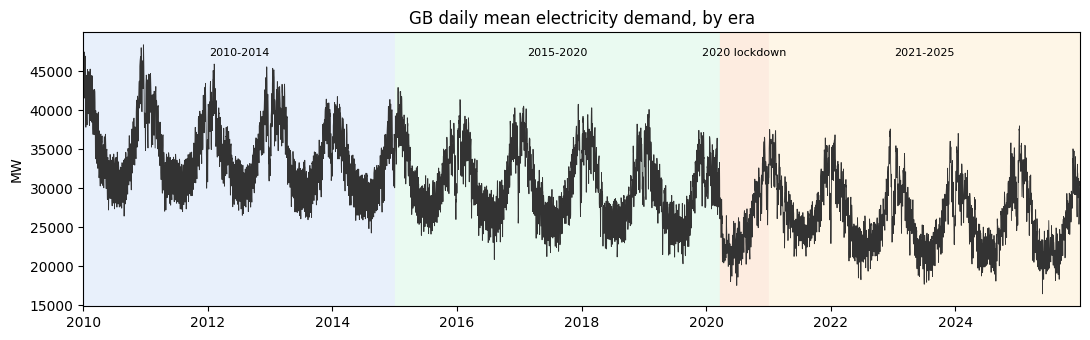

In [4]:
# Four contiguous eras, given as date ranges. RegimeSHAPAnalyzer resolves a
# {label: (start, end)} mapping into one regime label per row.
eras = {
    "2010-2014": ("2010-01-01", "2014-12-31"),      # higher-demand early decade, about 35 GW
    "2015-2020": ("2015-01-01", "2020-03-23"),      # settled lower level after the decline
    "2020 lockdown": ("2020-03-24", "2020-12-31"),  # pandemic anomaly, the short era
    "2021-2025": ("2021-01-01", "2025-12-31"),      # post-lockdown plateau, about 26 GW
}

# daily demand, shaded by era, so the decline and the eras are visible together
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(raw.index, raw["demand_mean"], linewidth=0.6, color="#333333")
band_colors = ["#e8f0fb", "#eafaf1", "#fdece0", "#fef6e7"]
for (label, (start, end)), c in zip(eras.items(), band_colors):
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=c)
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    ax.text(mid, raw["demand_mean"].max() * 0.97, label, ha="center", fontsize=8)
ax.set_title("GB daily mean electricity demand, by era")
ax.set_ylabel("MW")
ax.margins(x=0)
fig.tight_layout();

## Features and target

We build a simple day-ahead model: predict the **next day's demand** from what is known today.
The features are today's demand and the same weekday a week ago (the persistence a demand series
carries), a weekend flag for the weekly work cycle, two smooth terms for the annual cycle, and
the day's embedded wind and solar generation. We use a weekend flag rather than a raw day-of-week
number, which would impose a false ordering on the days.

In [5]:
df = pd.DataFrame(index=raw.index)
df["demand"] = raw["demand_mean"]                       # today's demand
df["demand_lag7"] = raw["demand_mean"].shift(7)         # same weekday last week
df["is_weekend"] = (raw.index.dayofweek >= 5).astype(int)
doy = raw.index.dayofyear
df["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)        # annual cycle, as two smooth terms
df["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
df["wind"] = raw["wind"]
df["solar"] = raw["solar"]

target = raw["demand_mean"].shift(-1).rename("demand_next")  # next-day demand

model_data = df.join(target).dropna()  # the lag and the shift leave NaNs at the edges
X = model_data.drop(columns="demand_next")
y = model_data["demand_next"]
print("design matrix:", X.shape)
X.head()

design matrix: (5836, 7)


,demand,demand_lag7,is_weekend,doy_sin,doy_cos,wind,solar
date,,,,,,,
2010-01-08,47256.7,36352.2,0,0.137185,0.990545,528.8,0.0
2010-01-09,42845.8,38258.5,1,0.154204,0.988039,944.5,0.0
2010-01-10,41538.8,38972.6,1,0.171177,0.985240,1319.2,0.0
2010-01-11,46875.0,45851.4,0,0.188099,0.982150,861.6,0.0
2010-01-12,46710.5,46750.1,0,0.204966,0.978769,1281.4,0.0


## Fit the model

A gradient-boosted tree again, fit on the whole history. As before this is a model to
interrogate, not a production demand forecast, and the in-sample fit just confirms it learned
something to explain.

In [6]:
model = XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, random_state=42
)
model.fit(X, y)
print(f"in-sample R^2: {model.score(X, y):.3f}")

in-sample R^2: 0.905


## Run the analysis

We pass the era mapping straight to the analyzer, and set `small_sample_threshold` to 500. The
four eras each span about five years, while the lockdown era spans about nine months, so this
threshold flags the one era much shorter than the others, the lockdown. This is a dataset-relative
choice, not a claim that nine months is too little data: it marks that a ranking estimated from
nine months carries more uncertainty than one from five years, which the bootstrap intervals
further down quantify.

In [7]:
analyzer = RegimeSHAPAnalyzer(model, X, eras, small_sample_threshold=500)
analyzer.global_importance().round(1)

demand         3937.199951
is_weekend      717.000000
demand_lag7     407.600006
doy_cos         170.899994
solar           170.000000
doy_sin         132.399994
wind            129.399994
Name: mean_abs_shap, dtype: float32

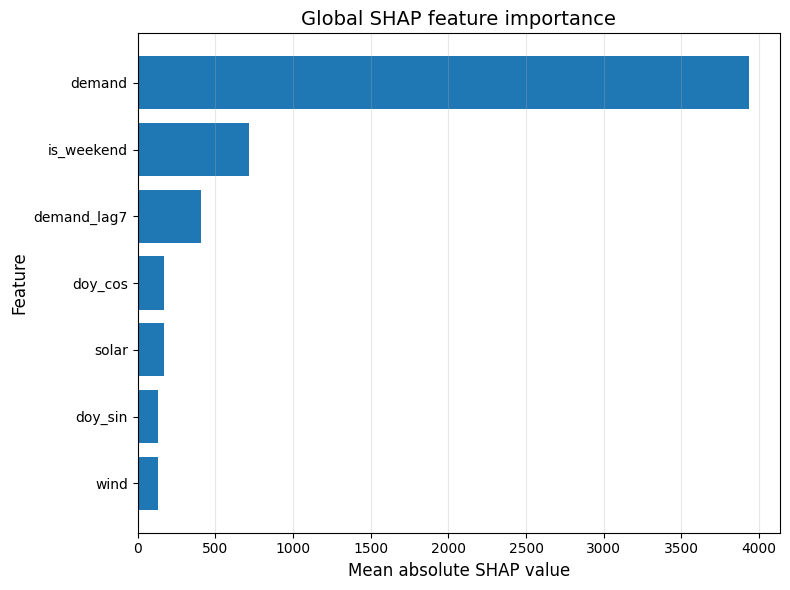

In [8]:
analyzer.plot_global();

## Per-regime rankings

The eras put their weight in broadly the same places, which is already a hint at the answer.

In [9]:
analyzer.per_regime_rankings()

,2010-2014,2015-2020,2020 lockdown,2021-2025
demand,1.0,1.0,1.0,1.0
demand_lag7,3.0,3.0,3.0,3.0
is_weekend,2.0,2.0,2.0,2.0
doy_sin,7.0,6.0,6.0,6.0
doy_cos,5.0,4.0,5.0,4.0
wind,6.0,7.0,7.0,7.0
solar,4.0,5.0,4.0,5.0


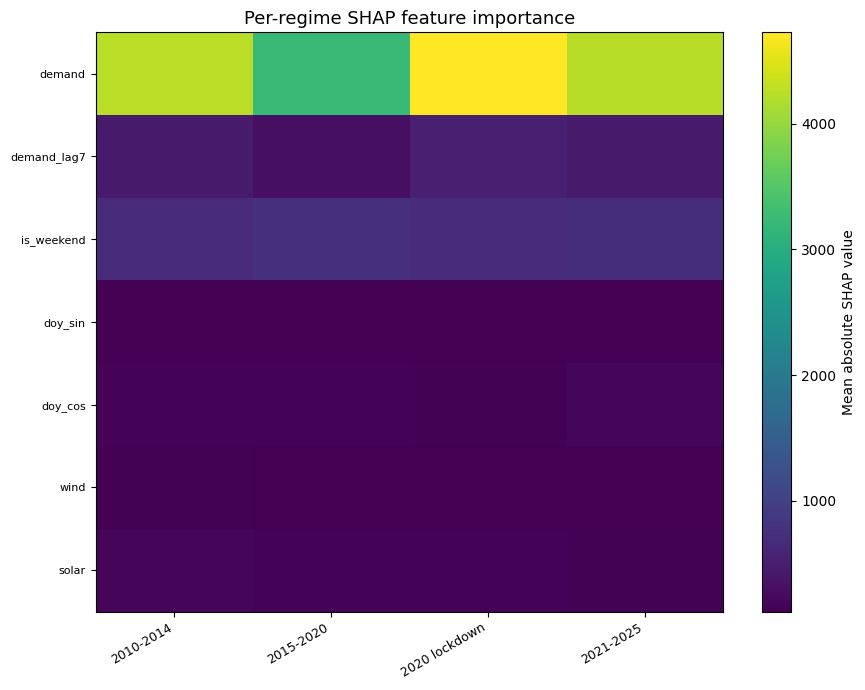

In [10]:
analyzer.plot_per_regime();

## Stability across regimes

Same reading as the finance notebook: each cell is the Spearman rank correlation between two
eras' importance rankings, and the Akoglu (2018) bands label it stable (rho above 0.6),
moderately stable (0.3 to 0.6), or unstable (0.3 or below).

In [11]:
analyzer.stability_matrix().round(3)

,2010-2014,2015-2020,2020 lockdown,2021-2025
2010-2014,1.000,0.929,0.964,0.929
2015-2020,0.929,1.000,0.964,1.000
2020 lockdown,0.964,0.964,1.000,0.964
2021-2025,0.929,1.000,0.964,1.000


In [12]:
analyzer.stability_classified()

,regime_a,regime_b,spearman_rho,band,involves_small_regime
0,2010-2014,2015-2020,0.928571,stable,False
1,2010-2014,2020 lockdown,0.964286,stable,True
2,2010-2014,2021-2025,0.928571,stable,False
3,2015-2020,2020 lockdown,0.964286,stable,True
4,2015-2020,2021-2025,1.000000,stable,False
5,2020 lockdown,2021-2025,0.964286,stable,True


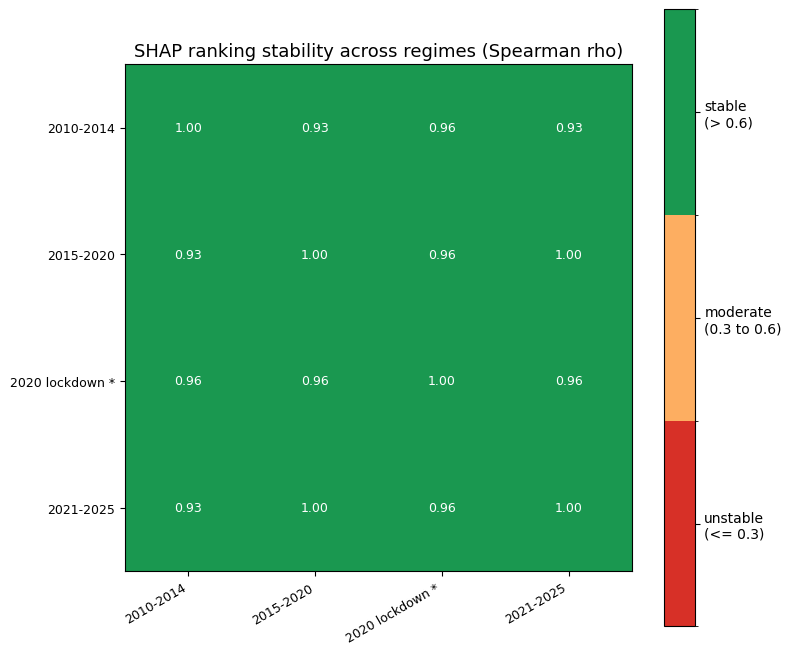

In [13]:
analyzer.plot_stability();

This is the opposite result to the finance notebook, and that is the point. The demand model's
drivers are **stable**: every era pair sits comfortably in the stable band. The drivers held
through the whole 2010s decline and through the 2020 lockdown, which is a genuinely useful thing
for a stability analysis to be able to confirm, not every model rests on shifting ground.

The one era that stands even slightly apart is the earliest, `2010-2014` (its correlations with
the later eras are around 0.93, the lowest in the matrix). That fits the history: embedded solar
was almost nothing before about 2013, so in the early era the renewable features rank a little
differently from later on, once solar had been built out. The regimes here are contiguous eras,
so the lockdown sits naturally among them as one more period rather than a different kind of thing.

## The short era, with bootstrap confidence intervals

Because the lockdown era is flagged small, the analyzer can attach a bootstrap confidence interval
to each of its stability correlations. It resamples the 283 lockdown days with replacement,
recomputes the ranking each time, and reports the range the correlation takes. The intervals have
real width, the honest message that a ranking from nine months is a little less certain than one
from five years, even though it still lands firmly in the stable band.

In [14]:
analyzer.sample_sizes()

,regime,n_observations,small_sample
0,2010-2014,1819,False
1,2015-2020,1909,False
2,2020 lockdown,283,True
3,2021-2025,1825,False


In [15]:
analyzer.bootstrap_cis(n_bootstrap=500).round(3)

,regime_a,regime_b,ci_lower,ci_upper,effective_n
0,2010-2014,2020 lockdown,0.893,1.0,283
1,2015-2020,2020 lockdown,0.929,1.0,283
2,2020 lockdown,2021-2025,0.910,1.0,283


## Save the results

The same export helpers as the finance notebook.

In [16]:
import tempfile
from pathlib import Path

out_dir = Path(tempfile.mkdtemp())
paths = analyzer.save_csv(out_dir)
html = analyzer.to_html(title="GB electricity demand: SHAP stability across demand eras")
print(f"wrote {len(paths)} CSV tables and a {len(html):,}-character HTML report to {out_dir}")

wrote 6 CSV tables and a 6,270-character HTML report to /var/folders/0m/7cd4sg3s2h9_28bz90nk68wr0000gn/T/tmp9zaz4ucv


## Adapt this to your own data

Between the two notebooks you have now seen both regime-input paths and both kinds of result:

- finance: regimes found from the data with `detect_breaks`, and drivers that **change** in a crisis;
- energy: regimes **labelled by hand** from domain knowledge, a short era read with bootstrap intervals, and drivers that **hold** across the eras.

The recipe is the same either way. Build a feature matrix and target, fit any
`shap.TreeExplainer`-compatible model, attach one regime label per row (found automatically or
from what you know about your data), and let `RegimeSHAPAnalyzer` tell you whether the model's
reasoning is stable where it needs to be.